# 06 — TEMPTED plots

Create plots of the TEMPTED subject components, temporal loading curves, metadata associations, feature loadings, and taxonomy.

The component 1-vs-2 country plot can be viewed beside the PCA and t-SNE plots from notebook 02.


In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, Normalize
import numpy as np
import pandas as pd

root = Path(".") if Path("data").exists() else Path("..")
processed = sorted((root / "data" / "processed_16s").iterdir())[-1]
prep = sorted((root / "data" / "preprocessing").iterdir())[-1]
meta_dir = sorted((root / "data" / "metadata_analysis").iterdir())[-1]
t_dir = sorted((root / "data" / "tempted").iterdir())[-1]
output = root / "data" / "figures" / datetime.now().strftime("%Y%m%d_%H%M%S")
output.mkdir(parents=True)

# load preprocessing, taxonomy, and TEMPTED outputs
coords = pd.read_csv(prep / "coordinates.csv")
taxonomy = pd.read_csv(processed / "taxonomy.csv")
tempted = pd.read_csv(meta_dir / "tempted_with_metadata.csv")
assoc = pd.read_csv(meta_dir / "metadata_associations.csv")
t_load = pd.read_csv(t_dir / "feature_loadings.csv")
t_time = pd.read_csv(t_dir / "temporal_loadings.csv")

t_dims = [c for c in tempted if c.startswith("component_")]

countries = ["FIN", "EST", "RUS"]
colors = {
    "FIN": "green",
    "EST": "blue",
    "RUS": "red",
}


In [2]:
# save a figure
def save(name, tight=True):
    if tight:
        plt.tight_layout()

    plt.savefig(output / name, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()


# shorten taxonomy labels
def short(value):
    return str(value).split("|")[-1].replace("g__", "")


## TEMPTED

The subject plots show the component space directly. The temporal loading curves show how each component changes over the longitudinal time axis.


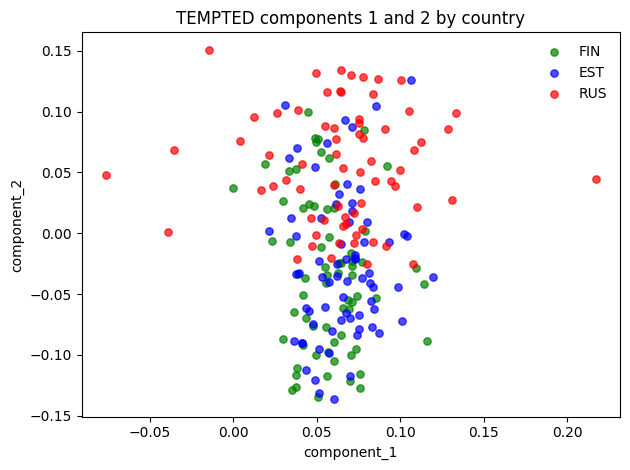

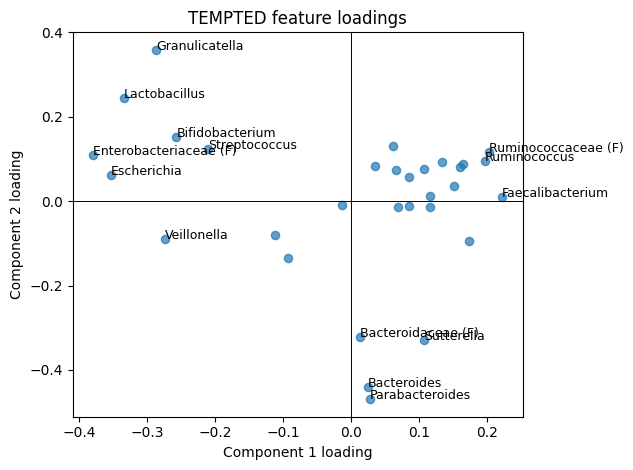

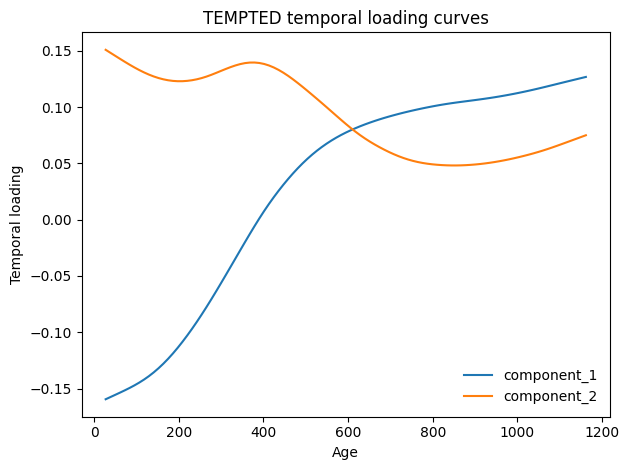

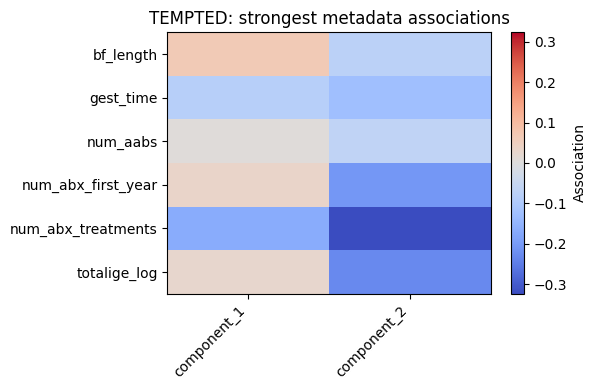

In [3]:
# plot component 1 vs component 2 by country
for country in countries:
    rows = tempted["country"] == country

    plt.scatter(
        tempted.loc[rows, t_dims[0]],
        tempted.loc[rows, t_dims[1]],
        s=28,
        alpha=.7,
        label=country,
        color=colors[country],
    )

plt.xlabel(t_dims[0])
plt.ylabel(t_dims[1])
plt.legend(frameon=False)
plt.title("TEMPTED components 1 and 2 by country")
save("tempted_components_1_2_country.png")


# plot feature loadings on components 1 and 2
plt.scatter(
    t_load[t_dims[0]],
    t_load[t_dims[1]],
    s=35,
    alpha=.7,
)

plt.axhline(
    0,
    color="black",
    linewidth=.7,
)

plt.axvline(
    0,
    color="black",
    linewidth=.7,
)

# find genera with the strongest combined loadings
labels = t_load[
    ["feature_id", t_dims[0], t_dims[1]]
].copy()

labels["strength"] = np.sqrt(
    labels[t_dims[0]] ** 2
    + labels[t_dims[1]] ** 2
)

labels = labels.nlargest(
    14,
    "strength",
)

# label the strongest genera
for row in labels.itertuples():
    plt.annotate(
        short(row.feature_id),
        (
            getattr(row, t_dims[0]),
            getattr(row, t_dims[1]),
        ),
        fontsize=9,
    )

plt.xlabel("Component 1 loading")
plt.ylabel("Component 2 loading")
plt.title("TEMPTED feature loadings")
save("tempted_feature_loadings_1_2.png")


# plot tempted temporal loading curves
for dim in t_dims:
    plt.plot(
        t_time["time"],
        t_time[dim],
        label=dim,
    )

plt.xlabel("Age")
plt.ylabel("Temporal loading")
plt.legend(frameon=False)
plt.title("TEMPTED temporal loading curves")
save("tempted_temporal_loadings.png")


# show metadata relationships in the subject components

t_assoc = assoc[assoc["method"] == "TEMPTED"]

t_strongest = (
    t_assoc.groupby("metadata")["absolute_association"]
    .max()
    .nlargest(12)
    .index
)

t_table = t_assoc[
    t_assoc["metadata"].isin(t_strongest)
].pivot(
    index="metadata",
    columns="dimension",
    values="association",
)

t_limit = np.nanmax(
    np.abs(
        t_table.to_numpy()
    )
)

t_norm = TwoSlopeNorm(
    vmin=-t_limit,
    vcenter=0,
    vmax=t_limit,
)

plt.figure(
    figsize=(
        max(6, .8 * len(t_dims)),
        max(4, .45 * len(t_table)),
    )
)

plt.imshow(
    t_table,
    aspect="auto",
    cmap="coolwarm",
    norm=t_norm,
)

plt.colorbar(label="Association")

plt.xticks(
    range(len(t_table.columns)),
    t_table.columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(t_table.index)),
    t_table.index,
)

plt.title("TEMPTED: strongest metadata associations")
save("tempted_metadata_heatmap.png")

## Genus loadings

These plots show which genera contribute most strongly to each TEMPTED component.


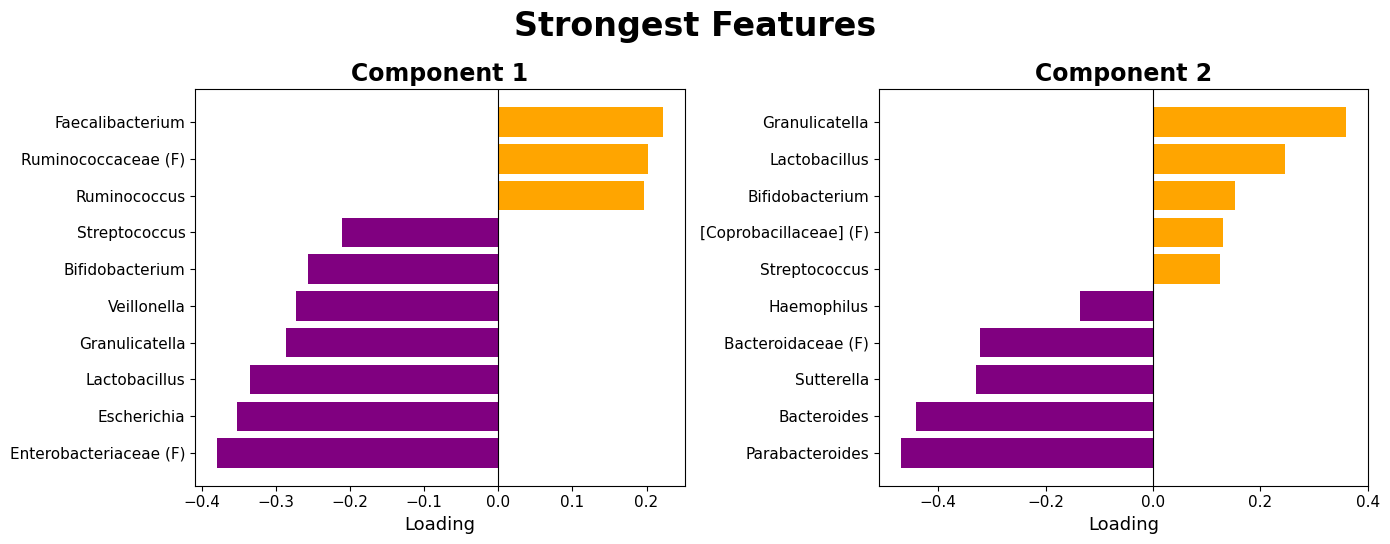

In [4]:
# plot the strongest genus loadings for each TEMPTED component

fig, axes = plt.subplots(
    1,
    len(t_dims),
    figsize=(7 * len(t_dims), 5.5),
)

axes = np.atleast_1d(axes)

for ax, dim in zip(axes, t_dims):
    top = t_load[["feature_id", dim]].copy()
    top["abs"] = top[dim].abs()
    top = top.nlargest(10, "abs").sort_values(dim)

    bar_colors = [
        "purple" if value < 0 else "orange"
        for value in top[dim]
    ]

    ax.barh(
        [short(x) for x in top["feature_id"]],
        top[dim],
        color=bar_colors,
    )

    ax.axvline(
        0,
        color="black",
        linewidth=.8,
    )

    number = dim.split("_")[-1]

    ax.set_title(
        f"Component {number}",
        fontsize=17,
        fontweight="bold",
    )

    ax.set_xlabel(
        "Loading",
        fontsize=13,
    )

    ax.tick_params(
        axis="both",
        labelsize=11,
    )

fig.suptitle(
    "Strongest Features",
    fontsize=24,
    fontweight="bold",
)

plt.tight_layout(rect=[0, .02, 1, .93])
save("strongest_genera.png")


## Circular Greengenes taxonomy plot

The taxonomy table comes from notebook 01. The tree uses the saved Greengenes hierarchy, and each tip uses the same feature name shown in the earlier TEMPTED feature plots. Unknown genera therefore appear as their closest known taxonomic level, such as `Lachnospiraceae (F)` or `Clostridiales (O)`.


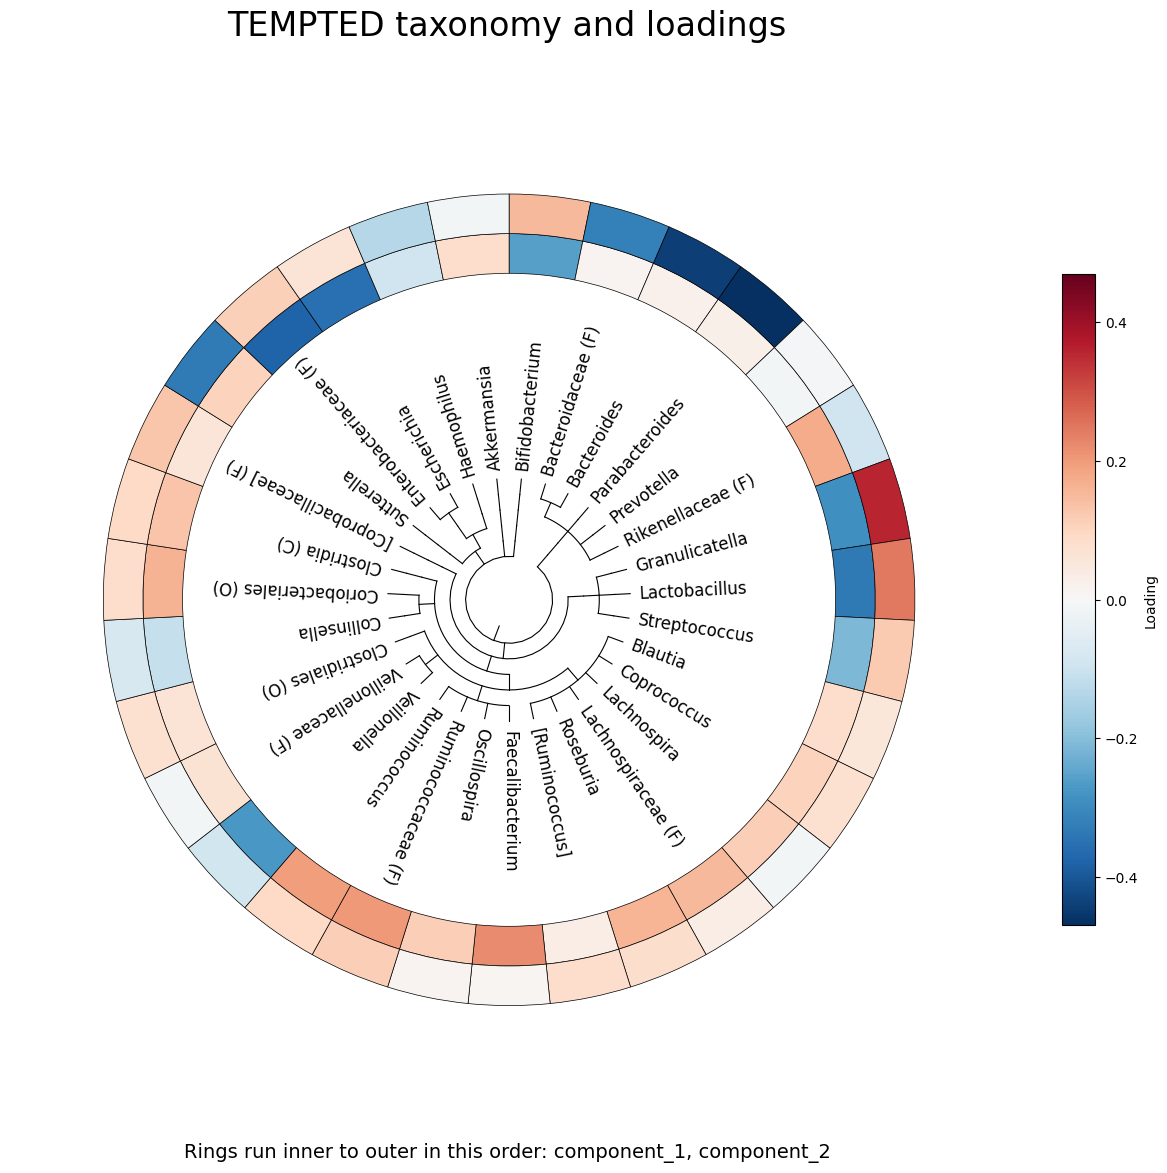

Saved: ../data/figures/20260818_152307


In [5]:
def taxonomy_ring(loadings, dims, title, filename):

    # keep taxonomy for the genera used by this model
    model_taxonomy = taxonomy[
        taxonomy["feature"].isin(loadings["feature_id"])
    ]

    # join taxonomy to the model loadings
    table = loadings.merge(
        model_taxonomy,
        left_on="feature_id",
        right_on="feature",
    )

    # use the display-ready feature name from notebook 01 as the tree tip
    table["tip"] = table["feature_id"]

    # rank features by their strongest loading
    table["importance"] = table[dims].abs().max(axis=1)

    # define the taxonomy levels
    ranks = [
        "kingdom",
        "phylum",
        "class",
        "order",
        "family",
        "tip",
    ]

    # make taxonomy paths
    paths = {}

    for row in table[["feature_id"] + ranks].itertuples(
        index=False,
        name=None,
    ):
        feature = row[0]
        path = tuple(str(x) for x in row[1:])
        paths[feature] = path

    # build the taxonomy tree
    children = {(): set()}

    for path in paths.values():
        for depth in range(1, len(ranks) + 1):
            parent = path[:depth - 1]
            node = path[:depth]

            children.setdefault(parent, set()).add(node)
            children.setdefault(node, set())

    # place genera evenly at the center of each ring cell
    tips = sorted(set(paths.values()))
    width = 2 * np.pi / len(tips)

    tip_angle = {
        tip: width * (i + .5)
        for i, tip in enumerate(tips)
    }

    # find all descendant genus angles for each taxonomy node
    def descendants(node):
        if node in tip_angle:
            return [tip_angle[node]]

        return sum(
            (descendants(child) for child in children[node]),
            [],
        )

    # place each taxonomy node at the center of its descendants
    angle = {}

    for node in children:
        a = descendants(node)

        if a:
            angle[node] = (
                np.angle(
                    np.mean(
                        np.exp(1j * np.array(a))
                    )
                )
                % (2 * np.pi)
            )

    # keep the taxonomy tree compact
    radius = {
        node: .06 + .20 * len(node) / len(ranks)
        for node in children
    }

    # set the loading color scale
    values = table.set_index("feature_id")

    limit = np.nanmax(
        np.abs(
            values[dims].to_numpy()
        )
    )

    # use a linear loading color scale centered on zero
    norm = Normalize(
        vmin=-limit,
        vmax=limit,
    )

    cmap = plt.get_cmap("RdBu_r")

    # make a large figure for readable labels
    fig, ax = plt.subplots(
        figsize=(14, 14),
        subplot_kw={"projection": "polar"},
    )

    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)
    ax.set_axis_off()

    # keep the loading rings thin and close to the labels
    ring_start = .70
    ring_width = .085

    ax.set_ylim(
        0,
        ring_start + len(dims) * ring_width + .20,
    )

    # draw the taxonomy tree
    for parent, kids in children.items():

        if parent not in angle or not kids:
            continue

        parent_angle = angle[parent]
        parent_radius = radius[parent]

        kids = sorted(kids)

        child_angles = np.array([
            angle[child]
            for child in kids
        ])

        unwrapped = (
            parent_angle
            + np.angle(
                np.exp(
                    1j * (child_angles - parent_angle)
                )
            )
        )

        # draw the branch joining sibling taxa
        if len(unwrapped) > 1:
            arc = np.linspace(
                unwrapped.min(),
                unwrapped.max(),
                25,
            )

            ax.plot(
                arc,
                np.full_like(arc, parent_radius),
                color="black",
                lw=.8,
            )

        # draw branches to the children
        for child, child_angle in zip(
            kids,
            unwrapped,
        ):
            ax.plot(
                [child_angle, child_angle],
                [parent_radius, radius[child]],
                color="black",
                lw=.8,
            )

    # match taxonomy tips back to feature IDs
    feature_for_tip = {
        path: feature
        for feature, path in paths.items()
    }

    # draw genus labels and loading rings
    for tip in tips:

        # use the same centered angle for tree, label, and ring cell
        a = tip_angle[tip]

        label = str(tip[-1])

        degrees = np.degrees(a) % 360

        # keep all labels moving around the circle in the same direction
        rotation = 90 - degrees

        # draw large bold genus labels
        ax.text(
            a,
            .28,
            label,
            rotation=rotation,
            rotation_mode="anchor",
            ha="left",
            va="center",
            fontsize=12,
        )

        feature = feature_for_tip[tip]

        # draw one centered ring cell for each component or factor
        for j, dim in enumerate(dims):

            value = values.loc[
                feature,
                dim,
            ]

            ax.bar(
                a,
                ring_width,
                width=width,
                bottom=ring_start + j * ring_width,
                color=cmap(norm(value)),
                edgecolor="black",
                lw=.5,
                align="center",
            )

    # position the polar plot
    ax.set_position([
        .07,   # left
        .095,  # bottom
        .82,   # width
        .81,   # height
    ])

    # anchor annotations to the actual polar-axis box
    box = ax.get_position()

    # place title immediately above the chart
    fig.text(
        box.x0 + box.width / 2,
        box.y1 - .012,
        title,
        ha="center",
        va="bottom",
        fontsize=24,
    )

    # add loading scale
    fig.colorbar(
        plt.cm.ScalarMappable(
            norm=norm,
            cmap=cmap,
        ),
        ax=ax,
        pad=.05,
        fraction=.03,
        label="Loading",
    )

    # place ring-order note immediately below the chart
    fig.text(
        box.x0 + box.width / 2,
        box.y0 + .012,
        "Rings run inner to outer in this order: "
        + ", ".join(dims),
        ha="center",
        va="top",
        fontsize=14,
    )

    save(filename, tight=False)


# draw taxonomy loading plots

taxonomy_ring(
    t_load,
    t_dims,
    "TEMPTED taxonomy and loadings",
    "tempted_taxonomy_ring.png",
)

print("Saved:", output)